In [7]:
import numpy as np
import neural_network
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Pixel value range:", X.min(), "to", X.max())

X shape: (70000, 784)
y shape: (70000,)
Pixel value range: 0 to 255


In [8]:
X= X/255.0

def one_hot(y, num_classes=10):
    n= len(y)
    encoded= np.zeros((n, num_classes))
    encoded[np.arange(n),y]=1
    return encoded
y_encoded= one_hot(y)

X_train, X_test, y_train, y_test= train_test_split(X, y_encoded, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (56000, 784)
y_train shape: (56000, 10)
X_test shape: (14000, 784)
y_test shape: (14000, 10)


In [11]:
import numpy as np
from neural_network import NeuralNetwork
from neural_network import sigmoid, relu, softmax
from neural_network import cross_entropy_loss, cross_entropy_loss_derivative

In [44]:
nn= NeuralNetwork([784,128,64,10])
epochs=20
batch_size=32
learning_rate= 0.01
losses= []
accuracies=[]

for epoch in range(epochs):
    indices= np.random.permutation(X_train.shape[0])
    X_shuffled= X_train[indices]
    y_shuffled= y_train[indices]
    epoch_loss=0
    
    for i in range(0, X_train.shape[0], 32):
        X_batch= X_shuffled[i:i+32]
        y_batch= y_shuffled[i:i+32]
        #print(f"Batch number: {i}")

        output= nn.forward(X_batch)
        loss= cross_entropy_loss(output,y_batch)
        epoch_loss+=loss

        grad= cross_entropy_loss_derivative(output,y_batch)
        nn.backward(grad,learning_rate) 

    test_output= nn.forward(X_test)
    preds= np.argmax(test_output, axis=1)
    true_labels= np.argmax(y_test, axis=1)
    accuracy= np.mean(preds==true_labels)

    losses.append(epoch_loss)
    accuracies.append(accuracy)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Accuracy: {accuracy:.4f}")



    
        
        
    
    

Epoch 1/20 | Loss: 1173.9446 | Accuracy: 0.9029
Epoch 2/20 | Loss: 521.8987 | Accuracy: 0.9248
Epoch 3/20 | Loss: 424.5302 | Accuracy: 0.9331
Epoch 4/20 | Loss: 363.1571 | Accuracy: 0.9416
Epoch 5/20 | Loss: 319.0608 | Accuracy: 0.9466
Epoch 6/20 | Loss: 284.7434 | Accuracy: 0.9509
Epoch 7/20 | Loss: 257.5138 | Accuracy: 0.9529
Epoch 8/20 | Loss: 236.3151 | Accuracy: 0.9561
Epoch 9/20 | Loss: 216.8903 | Accuracy: 0.9581
Epoch 10/20 | Loss: 199.9805 | Accuracy: 0.9607
Epoch 11/20 | Loss: 186.2645 | Accuracy: 0.9609
Epoch 12/20 | Loss: 173.8990 | Accuracy: 0.9637
Epoch 13/20 | Loss: 162.3264 | Accuracy: 0.9646
Epoch 14/20 | Loss: 152.0319 | Accuracy: 0.9648
Epoch 15/20 | Loss: 143.2294 | Accuracy: 0.9651
Epoch 16/20 | Loss: 134.2432 | Accuracy: 0.9666
Epoch 17/20 | Loss: 126.8705 | Accuracy: 0.9671
Epoch 18/20 | Loss: 119.5937 | Accuracy: 0.9682
Epoch 19/20 | Loss: 113.4506 | Accuracy: 0.9688
Epoch 20/20 | Loss: 106.7154 | Accuracy: 0.9696


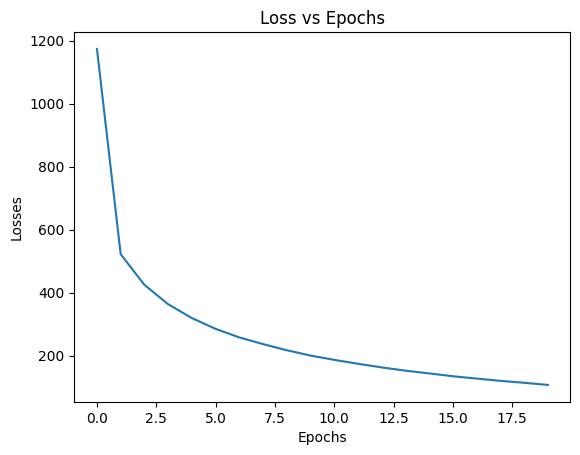

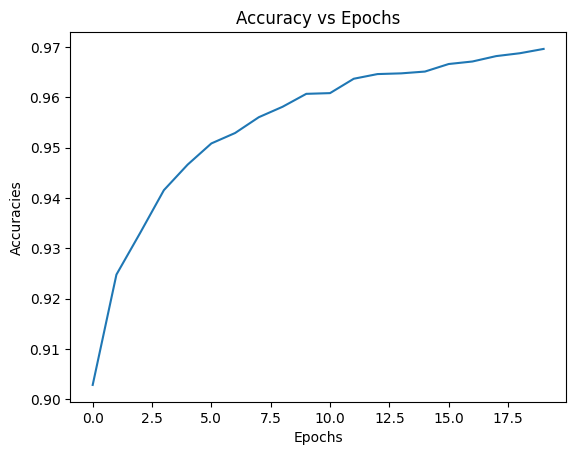

In [45]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.show()

plt.plot(accuracies)
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracies")
plt.show()


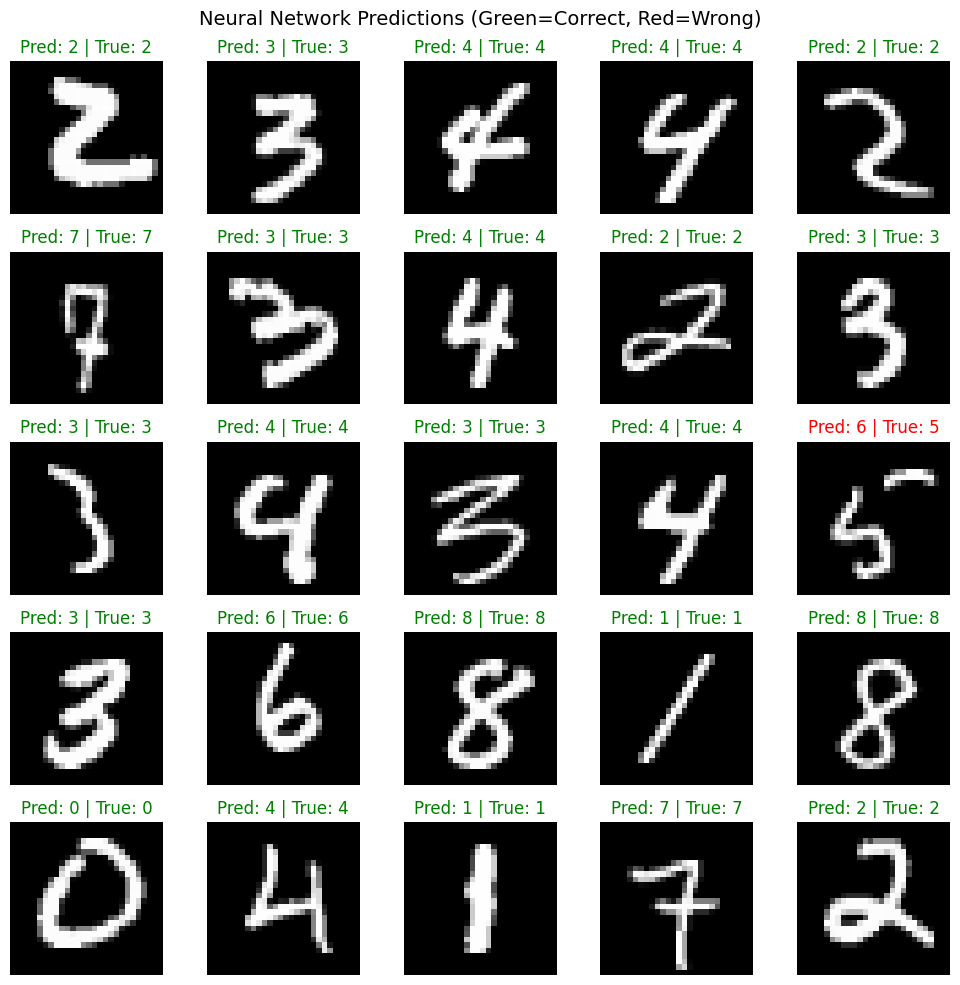

In [46]:
import matplotlib.pyplot as plt

# Get test predictions
test_output = nn.forward(X_test)
predictions = np.argmax(test_output, axis=1)
true_labels = np.argmax(y_test, axis=1)

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
indices = np.random.choice(len(X_test), 25, replace=False) #Plots 25 random test cases

for ax, idx in zip(axes.flat, indices):
    image = X_test[idx].reshape(28, 28)
    pred = predictions[idx]
    true = true_labels[idx]
    color = 'green' if pred == true else 'red'
    ax.imshow(image, cmap='gray')
    ax.set_title(f"Pred: {pred} | True: {true}", color=color)
    ax.axis('off')

plt.suptitle('Neural Network Predictions (Green=Correct, Red=Wrong)', 
             fontsize=14)
plt.tight_layout()
plt.show()